# 05b — Graph Autoencoder (GAE / VGAE): Grafo de Grupos (G)Este notebook entrena un **Graph Autoencoder (GAE)** y un **Variational Graph Autoencoder (VGAE)** sobre el grafo de grupos `G` del dataset Meetup Tennessee, con el objetivo de detectar grupos estructuralmente anómalos.## ContextoEl grafo `G` contiene **456 nodos** (grupos con co-membresía) y **13.384 aristas dirigidas** en `edge_index` — equivalentes a **6.692 aristas únicas no dirigidas**. Cada nodo tiene **35 features** procedentes del notebook 04: `log_num_members`, `log_num_events`, `is_truncated`, `has_valid_organizer` y un one-hot de las 31 categorías temáticas.## Esquema del notebook| Sección | Contenido ||---------|-----------|| 0 | Imports y configuración || 1 | Carga del grafo y verificación || 2 | Diferencias respecto al grafo M y consecuencias para el modelo || 3 | Split de aristas || 4 | Arquitectura del GAE — teoría y decisiones || 5 | Entrenamiento del GAE || 6 | Anomaly scores (GAE) || 7 | Arquitectura y entrenamiento del VGAE || 8 | Anomaly scores (VGAE) || 9 | Comparativa GAE vs VGAE || 10 | Análisis de anomalías detectadas || 11 | Guardado de resultados |

## 0. Imports y configuraciónCargamos las mismas librerías que en el notebook 05a — el stack es idéntico (PyTorch, PyTorch Geometric, scikit, matplotlib). Fijamos las mismas semillas para reproducibilidad. La elección de la **misma seed** que en 05a es deliberada: cuando comparemos resultados entre grafos en la sección 7.4 del TFM queremos que las diferencias se deban al grafo y al modelo, no a la inicialización aleatoria.

In [2]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GAE, VGAE
from torch_geometric.utils import negative_sampling
from torch_geometric.transforms import RandomLinkSplit
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Paths
GRAPH_DATA_PATH = '../data/graph_data/'
PROCESSED_PATH  = '../data/processed/'
RESULTS_PATH    = '../data/results/'
os.makedirs(RESULTS_PATH, exist_ok=True)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Carga del grafo G y verificaciónCargamos el objeto `Data` del grafo de grupos, junto a `meta_groups` para poder interpretar después qué grupo concreto está detrás de cada nodo. Verificamos que las dimensiones coinciden con lo esperado: 456 nodos, 13.384 aristas en formato dirigido (6.692 únicas) y 35 features.

In [3]:
# Cargamos el objeto Data del grafo G
data_G = torch.load(os.path.join(GRAPH_DATA_PATH, 'data_G.pt'), weights_only=False)

print(data_G)
print(f'\nNodos          : {data_G.num_nodes}')
print(f'Aristas (dirig.): {data_G.num_edges}')
print(f'Aristas únicas : {data_G.num_edges // 2}')
print(f'Features/nodo  : {data_G.num_node_features}')
print(f'Es no dirigido : {data_G.is_undirected()}')

Data(x=[456, 35], edge_index=[2, 13384], edge_weight=[13384], group_ids=[456])

Nodos          : 456
Aristas (dirig.): 13384
Aristas únicas : 6692
Features/nodo  : 35
Es no dirigido : True


In [4]:
# Cargamos meta_groups para interpretar resultados
meta_groups = pd.read_csv(os.path.join(PROCESSED_PATH, 'meta-groups.csv'))
print(f'meta_groups: {meta_groups.shape}')
meta_groups.head()

meta_groups: (602, 7)


,group_id,group_name,num_members,category_id,category_name,organizer_id,group_urlname
0,339011,Nashville Hiking Meetup,15838,23,Outdoors & Adventure,4353803,nashville-hiking
1,19728145,Stepping Out Social Dance Meetup,1778,5,Dancing,118484462,steppingoutsocialdance
2,6335372,Nashville soccer,2869,32,Sports & Recreation,108448302,Nashville-soccer
3,10016242,NashJS,1975,34,Tech,8111102,nashjs
4,21174496,20's & 30's Women looking for girlfriends,2782,31,Socializing,184580248,new-friends-in-Nashville


## 2. Diferencias respecto al grafo M y consecuencias para el modeloAntes de definir la arquitectura conviene entender en qué se diferencia este grafo del de miembros, porque las decisiones de hiperparámetros van a ser distintas en varios puntos importantes.### 2.1 Comparativa cuantitativa| Aspecto | Grafo M | Grafo G ||---|---|---|| Nº nodos | 11.371 | 456 || Nº aristas únicas | 1.176.184 | 6.692 || Features por nodo | 3 | 35 || Densidad | 0.0182 | 0.0645 || Modularidad Louvain | 0.6755 | 0.4427 || Clustering medio | 0.885 | 0.5488 || Grado medio | 206.89 | 29.35 |### 2.2 Consecuencia 1 — Riesgo de sobreajuste mucho mayorEl **sobreajuste** ocurre cuando un modelo tiene tantos parámetros respecto a los datos que en lugar de aprender patrones generales acaba **memorizando casos concretos** del conjunto de entrenamiento. Un modelo sobreajustado funciona perfectamente sobre los datos que ha visto pero falla con datos nuevos — y para nuestro objetivo (detección de anomalías) esto es especialmente dañino: si el modelo memoriza el grafo, reconstruye perfectamente *todos* los nodos, incluyendo los anómalos, y entonces ningún nodo destaca por error de reconstrucción.La forma habitual de medir el riesgo de sobreajuste es la **ratio de parámetros por dato**. En el grafo M, un encoder GCN de capas (3 → 32 → 16) tiene aproximadamente `3·32 + 32·16 ≈ 608` parámetros, repartidos entre 11.371 nodos: unos **0.05 parámetros por nodo**. En el grafo G, manteniendo dimensiones similares (35 → 32 → 16), serían `35·32 + 32·16 ≈ 1.632` parámetros para 456 nodos: **3.6 parámetros por nodo**, **70 veces más**. El modelo tiene espacio de sobra para memorizar.Para mitigar este riesgo aumentamos la regularización por tres vías complementarias, que se aplican simultáneamente:**Dropout más alto (0.4 frente a 0.2 en M).** El dropout es una técnica de regularización que durante el entrenamiento **desactiva aleatoriamente** una fracción de las neuronas en cada paso. Con dropout 0.4, cada época un 40% de las activaciones se ponen a cero, lo que obliga al modelo a no depender de ninguna neurona individual y aprender representaciones redundantes y robustas. En grafos pequeños y densamente parametrizados como G, el dropout es la primera línea de defensa contra la memorización.**Weight decay en el optimizador (regularización L2).** El weight decay es una penalización que añade $\lambda \sum_i w_i^2$ a la función de pérdida, donde $w_i$ son los pesos del modelo y $\lambda$ es un coeficiente pequeño (usamos $5\cdot10^{-4}$). Esta penalización empuja a los pesos a permanecer pequeños — y los pesos pequeños generan funciones más suaves y menos propensas a memorizar valores extremos. Es una técnica clásica de redes neuronales, particularmente efectiva cuando hay muchas features de entrada como aquí.**Dimensión latente más pequeña (8 frente a 16 en M).** El cuello de botella del autoencoder es donde se decide cuánta información puede pasar del encoder al decoder. Una dimensión latente alta permite al modelo guardar información detallada de cada nodo — incluyendo idiosincrasias que no son útiles para reconstruir patrones generales. Forzar una dimensión latente más pequeña obliga al modelo a **comprimir más agresivamente**, manteniendo solo lo esencial. Para 456 nodos, 8 dimensiones siguen siendo suficientes para representar las comunidades temáticas que vimos en el EDA.### 2.3 Consecuencia 2 — Menor modularidad implica anomalías más sutilesLa **modularidad** es una métrica que mide cuánto se parece la estructura de comunidades de un grafo a la de un grafo aleatorio con la misma distribución de grados. Vale 1 cuando las comunidades están perfectamente separadas (las aristas están todas dentro de comunidades, ninguna entre ellas) y 0 cuando no hay estructura de comunidad (las aristas están distribuidas como por azar). Valores por encima de 0.3 ya se consideran indicativos de estructura de comunidad significativa.El grafo M tiene modularidad **0.6755** — comunidades muy bien definidas, con la mayor parte de aristas dentro de comunidades temáticas (Tech, Outdoors, Dancing, etc.). El grafo G tiene modularidad **0.4427** — significativamente menor. Esto significa que **muchos grupos comparten miembros con grupos de categorías distintas**: los miembros de un grupo de tecnología también están en grupos de socializing, los de outdoors también en singles, etc.Para la detección de anomalías esto tiene una implicación importante: en el grafo G **el patrón normal ya incluye conexiones inter-comunidad**. Por tanto, un grupo que conecta con otras comunidades no es per se anómalo — la anomalía será un grupo cuyo patrón de mezcla sea **inusual incluso en este contexto de mezcla**. Esto exige al modelo aprender representaciones más finas y los scores de anomalía serán necesariamente más comprimidos en su rango (menos contraste entre el nodo más anómalo y el menos).### 2.4 Consecuencia 3 — Features mucho más informativasEn el grafo M las features eran 3 dimensiones de información geográfica. En G tenemos 35 dimensiones que codifican tamaño (`log_num_members`), actividad (`log_num_events`), señales de calidad (`is_truncated`, `has_valid_organizer`) y categoría temática (one-hot de 31 dimensiones). El GCN dispone de mucha más información de partida.Esto tiene un efecto positivo y otro negativo. El **positivo** es que el modelo puede combinar información topológica (vecinos) con información semántica (categoría, tamaño), lo que potencialmente permite detectar anomalías más interpretables. Por ejemplo: un grupo de Tech aislado de otros grupos de Tech es estructuralmente sospechoso, y eso solo es identificable cruzando la categoría con la topología.El **negativo** es que los nodos con features muy diferenciadas (categorías minoritarias como Cars & Motorcycles con solo 2 grupos) ya son intrínsecamente *features-outliers*, y esto se mezcla con la noción de outlier topológico que queremos detectar. El modelo puede asignar scores altos a esos nodos no por ser estructuralmente anómalos sino por tener combinaciones de features poco frecuentes. Lo abordaremos en la fase de análisis.

## 3. Split de aristasAplicamos `RandomLinkSplit` con la misma proporción que en M (85/5/10). En un grafo de solo 6.692 aristas únicas estas proporciones nos dejan aproximadamente 5.688 aristas de entrenamiento, 335 de validación y 669 de test — números modestos pero suficientes para evaluar AUC y AP con varianza razonable.**Por qué no separamos nodos.** Conviene insistir en este punto porque genera confusión. En un autoencoder clásico sobre tabular data se separan filas (muestras) en train/test. Aquí no podemos hacer eso: la GCN que sirve de encoder propaga información a través de las aristas del grafo, y si quitamos un nodo del entrenamiento sus vecinos también pierden información. Lo que se separan son **aristas**: el modelo ve todos los nodos durante el entrenamiento pero solo un subconjunto de las conexiones, y se evalúa por su capacidad de predecir las conexiones que no vio.

In [5]:
transform = RandomLinkSplit(
    num_val=0.05,
    num_test=0.10,
    is_undirected=True,
    add_negative_train_samples=False,
    split_labels=True,
)

train_data, val_data, test_data = transform(data_G)

print('=== Split de aristas ===')
print(f'Train edges (positivos): {train_data.pos_edge_label_index.shape[1]}')
print(f'Val   edges (positivos): {val_data.pos_edge_label_index.shape[1]}')
print(f'Val   edges (negativos): {val_data.neg_edge_label_index.shape[1]}')
print(f'Test  edges (positivos): {test_data.pos_edge_label_index.shape[1]}')
print(f'Test  edges (negativos): {test_data.neg_edge_label_index.shape[1]}')

train_data = train_data.to(device)
val_data   = val_data.to(device)
test_data  = test_data.to(device)

=== Split de aristas ===
Train edges (positivos): 5689
Val   edges (positivos): 334
Val   edges (negativos): 334
Test  edges (positivos): 669
Test  edges (negativos): 669


## 4. Arquitectura del GAE — teoría y decisiones### 4.1 Recordatorio teórico — Graph AutoencoderAntes de definir el modelo, repasemos la formulación teórica del GAE (Kipf & Welling, 2016) ya presentada en el notebook 05a, para tener todos los conceptos a mano.Un autoencoder clásico aprende dos funciones: un encoder $f: \mathbb{R}^{n \times d} \to \mathbb{R}^{n \times k}$ que comprime los datos en una representación latente, y un decoder $g: \mathbb{R}^{n \times k} \to \mathbb{R}^{n \times d}$ que reconstruye los datos originales desde el latente. El modelo se entrena minimizando el error de reconstrucción $\| g(f(X)) - X \|^2$. La idea clave es que un cuello de botella estrecho ($k \ll d$) fuerza al modelo a aprender solo las dimensiones más importantes de los datos — descartando ruido e idiosincrasias.Un **Graph Autoencoder** adapta esta idea a grafos cambiando dos cosas:**Primero, el encoder es una Graph Convolutional Network (GCN).** Una GCN no procesa cada nodo independientemente sino que **agrega información de los vecinos** en cada capa. La actualización de la representación de un nodo $v$ en la capa $\ell+1$ es:$$h_v^{(\ell+1)} = \sigma\left( W^{(\ell)} \sum_{u \in \mathcal{N}(v) \cup \{v\}} \frac{1}{\sqrt{\tilde{d}_v \tilde{d}_u}} h_u^{(\ell)} \right)$$donde $\mathcal{N}(v)$ son los vecinos de $v$, $\tilde{d}_v = d_v + 1$ es el grado de $v$ con self-loop, $W^{(\ell)}$ es la matriz de pesos aprendibles de la capa $\ell$, y $\sigma$ es la función de activación (típicamente ReLU). En forma matricial, esto se escribe de forma compacta como:$$H^{(\ell+1)} = \sigma(\tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2} H^{(\ell)} W^{(\ell)})$$donde $\tilde{A} = A + I$ es la matriz de adyacencia con self-loops y $\tilde{D}$ es su matriz de grados. La expresión $\tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2}$ es la **matriz de adyacencia normalizada simétrica**, que evita que los nodos de alto grado dominen la propagación de mensajes.Apilando dos capas de GCN obtenemos el encoder completo:$$Z = \text{GCN}(X, A) = \tilde{A}_{norm} \cdot \text{ReLU}(\tilde{A}_{norm} X W^{(0)}) \cdot W^{(1)}$$La salida $Z \in \mathbb{R}^{n \times k}$ es el conjunto de embeddings latentes — un vector $z_i$ por nodo, de dimensión $k$.**Segundo, el decoder es un producto interno seguido de sigmoide.** En lugar de reconstruir las features $X$, el GAE reconstruye la **matriz de adyacencia** $A$:$$\hat{A}_{ij} = \sigma(z_i^T z_j) = \frac{1}{1 + \exp(-z_i^T z_j)}$$La intuición es geométrica: dos nodos cuyos embeddings son similares (producto interno alto, dirección parecida) se interpretan como conectados. El decoder no tiene parámetros propios — toda la información reside en los embeddings, lo que fuerza al encoder a aprender representaciones útiles.### 4.2 ¿Por qué este diseño es útil para detección de anomalías?Los GAE no se diseñaron originalmente para detectar anomalías sino para tareas como predicción de enlaces. Sin embargo, son ideales para anomalías porque:1. **Son no supervisados.** No necesitan ejemplos etiquetados de anomalías — algo crucial en nuestro problema, donde las anomalías son por definición desconocidas a priori.2. **El error de reconstrucción es interpretable.** Un nodo cuyo patrón de conexiones no se reconstruye bien es uno cuya estructura local es atípica respecto al patrón global aprendido por el modelo.3. **Combinan estructura y atributos.** A diferencia de métricas estructurales puras (degree, betweenness, clustering), un GAE integra las features de los nodos con la topología, captando anomalías que requieren mirar ambas dimensiones a la vez.### 4.3 Decisiones de hiperparámetros para el grafo GComparamos las elecciones del notebook 05a (grafo M) y este (grafo G), explicando cada una:| Hiperparámetro | M (05a) | G (este) | Justificación del cambio ||---|---|---|---|| Dimensión oculta | 32 | 32 | Sin cambio — sirve igual de cuello de botella intermedio || Dimensión latente | 16 | **8** | Más compresión: con 456 nodos, 16 permite memorizar || Dropout | 0.2 | **0.4** | Ratio parámetros/nodo 70× mayor — más regularización || Weight decay | 0 | **5e-4** | L2 sobre pesos para evitar memorización || Learning rate | 0.01 | **0.005** | LR más conservador con menos datos || Épocas máx | 200 | 300 | Margen extra (las épocas baratas en G — solo 6.7k aristas) || Patience early stopping | 20 | 30 | Más paciencia: con tan pocas aristas, val AUC fluctúa más |

In [6]:
class GCNEncoder(nn.Module):
    """
    Encoder GCN de dos capas para el GAE — versión con dropout más alto
    para el grafo G.
    """
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.4):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels, cached=True)
        self.conv2 = GCNConv(hidden_channels, out_channels, cached=True)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x


HIDDEN_DIM = 32
LATENT_DIM = 8       # Más pequeño que en M (16) — fuerza más compresión
DROPOUT    = 0.4     # Más alto que en M (0.2)
IN_DIM     = data_G.num_node_features

model_gae = GAE(GCNEncoder(IN_DIM, HIDDEN_DIM, LATENT_DIM, dropout=DROPOUT)).to(device)
print(model_gae)

# Recuento de parámetros — útil para confirmar el riesgo de sobreajuste
n_params = sum(p.numel() for p in model_gae.parameters() if p.requires_grad)
print(f'\nParámetros entrenables: {n_params}')
print(f'Nodos                 : {data_G.num_nodes}')
print(f'Ratio parámetros/nodo : {n_params / data_G.num_nodes:.2f}')

GAE(
  (encoder): GCNEncoder(
    (conv1): GCNConv(35, 32)
    (conv2): GCNConv(32, 8)
  )
  (decoder): InnerProductDecoder()
)

Parámetros entrenables: 1416
Nodos                 : 456
Ratio parámetros/nodo : 3.11


## 5. Entrenamiento del GAE### 5.1 Función de pérdida — recordatorioEl GAE se entrena minimizando la **entropía cruzada binaria** sobre las aristas del grafo:$$\mathcal{L} = -\frac{1}{|E^+|} \sum_{(i,j) \in E^+} \log \hat{A}_{ij} - \frac{1}{|E^-|} \sum_{(i,j) \in E^-} \log(1 - \hat{A}_{ij})$$donde $E^+$ son las aristas reales (positivas) y $E^-$ son aristas muestreadas aleatoriamente entre nodos no conectados (negativas). El método `recon_loss` de PyG implementa esto directamente, generando el muestreo negativo de forma dinámica en cada época (cada época ve un conjunto distinto de negativos, lo cual añade ruido beneficioso).### 5.2 Optimizador — Adam con weight decayUsamos **Adam**, el optimizador estándar en deep learning. Adam combina dos ideas: momentum (acumular gradientes pasados para suavizar la dirección de actualización) y adaptación por parámetro de la tasa de aprendizaje (cada peso tiene su propia escala efectiva). Es robusto a la elección del learning rate y converge bien con poca configuración.La novedad respecto al notebook M es el **weight decay**. En PyTorch este parámetro se pasa al optimizador y se interpreta como el coeficiente $\lambda$ que multiplica $\sum_i w_i^2$ en la pérdida regularizada. Un valor de $5 \cdot 10^{-4}$ es un valor estándar — suficiente para penalizar pesos grandes sin estrangular el aprendizaje.### 5.3 Early stopping — más pacienciaCon tan pocas aristas en validación (335 positivas + 335 negativas), el AUC fluctúa más entre épocas. Aumentamos la paciencia de 20 a 30 para no interrumpir el entrenamiento por una mala época puntual. La métrica que monitorizamos sigue siendo Val AUC.

In [7]:
def train_epoch(model, data, optimizer):
    """Una época de entrenamiento del GAE."""
    model.train()
    optimizer.zero_grad()
    z = model.encode(data.x, data.edge_index)
    loss = model.recon_loss(z, data.pos_edge_label_index)
    loss.backward()
    optimizer.step()
    return float(loss)


@torch.no_grad()
def eval_split(model, data):
    model.eval()
    z = model.encode(data.x, data.edge_index)
    auc, ap = model.test(z, data.pos_edge_label_index, data.neg_edge_label_index)
    return auc, ap

In [8]:
# Configuración del entrenamiento — ver tabla en sección 4.3
LR           = 0.005    # Más conservador que en M (0.01)
WEIGHT_DECAY = 5e-4     # L2 — clave en G por la ratio params/nodo
EPOCHS       = 300
PATIENCE     = 30

optimizer = torch.optim.Adam(model_gae.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

history_gae = {'loss': [], 'val_auc': [], 'val_ap': []}
best_val_auc = 0.0
best_epoch = 0
patience_counter = 0
best_state = None

for epoch in range(1, EPOCHS + 1):
    loss = train_epoch(model_gae, train_data, optimizer)
    val_auc, val_ap = eval_split(model_gae, val_data)

    history_gae['loss'].append(loss)
    history_gae['val_auc'].append(val_auc)
    history_gae['val_ap'].append(val_ap)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch = epoch
        patience_counter = 0
        best_state = {k: v.detach().clone() for k, v in model_gae.state_dict().items()}
    else:
        patience_counter += 1

    if epoch % 20 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | Loss {loss:.4f} | Val AUC {val_auc:.4f} | Val AP {val_ap:.4f}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping en época {epoch}. Mejor época: {best_epoch} (Val AUC {best_val_auc:.4f})')
        break

if best_state is not None:
    model_gae.load_state_dict(best_state)

test_auc, test_ap = eval_split(model_gae, test_data)
print(f'\n=== Resultados finales GAE ===')
print(f'Test AUC: {test_auc:.4f}')
print(f'Test AP : {test_ap:.4f}')

Epoch   1 | Loss 1.2947 | Val AUC 0.8660 | Val AP 0.8688
Epoch  20 | Loss 1.1707 | Val AUC 0.8577 | Val AP 0.8660

Early stopping en época 35. Mejor época: 5 (Val AUC 0.8661)

=== Resultados finales GAE ===
Test AUC: 0.8740
Test AP : 0.8772


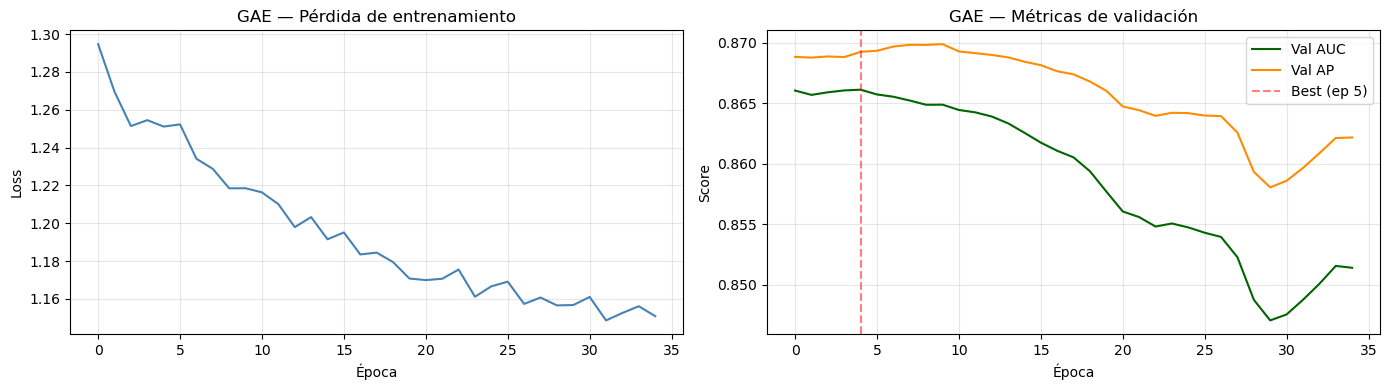

In [9]:
# Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_gae['loss'], color='steelblue')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].set_title('GAE — Pérdida de entrenamiento')
axes[0].grid(alpha=0.3)

axes[1].plot(history_gae['val_auc'], label='Val AUC', color='darkgreen')
axes[1].plot(history_gae['val_ap'],  label='Val AP',  color='darkorange')
axes[1].axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.5, label=f'Best (ep {best_epoch})')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Score')
axes[1].set_title('GAE — Métricas de validación')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Cálculo de anomaly scores (GAE)### 6.1 Recordatorio teórico — los dos scoresComo en el notebook 05a, calculamos dos scores complementarios por nodo:**Score 1 — Error de reconstrucción de adyacencia.** Para cada nodo $i$ comparamos su fila real de la matriz de adyacencia $A_i \in \{0, 1\}^n$ con su fila reconstruida $\hat{A}_i = \sigma(Z z_i^T) \in [0,1]^n$. La métrica de error es **BCE por elemento promediada por fila**:$$s^{rec}_i = -\frac{1}{n}\sum_{j} A_{ij} \log \hat{A}_{ij} + (1 - A_{ij}) \log(1 - \hat{A}_{ij})$$Un score alto significa que el modelo no consigue predecir correctamente las conexiones del nodo — su patrón de conectividad es atípico.**Score 2 — Distancia del embedding al centroide.** Calculamos el centroide de todos los embeddings $\bar{z} = \frac{1}{n}\sum_i z_i$ y para cada nodo medimos:$$s^{lat}_i = \| z_i - \bar{z} \|_2$$La intuición es que el centro del espacio latente concentra los patrones más comunes. Los nodos cuyos embeddings se alejan del centroide son potencialmente anómalos. Esta intuición se apoya en literatura clásica de detección de outliers (Mahalanobis, OneClassSVM): los puntos lejanos del centro de masa son los más sospechosos.### 6.2 Implementación específica para GA diferencia del grafo M, donde la matriz de adyacencia 11.371 × 11.371 requería procesado por bloques, en G la matriz es de solo 456 × 456 — caben todas las predicciones de adyacencia en memoria sin problema. Esto **simplifica el código** y permite vectorizar la operación completa en una única multiplicación de matrices.Este detalle es importante para el TFM porque ilustra cómo un mismo algoritmo conceptual se implementa de forma distinta según el tamaño del grafo, sin afectar a la corrección del resultado.

In [10]:
@torch.no_grad()
def get_embeddings(model, data):
    """Devuelve los embeddings latentes Z usando todas las aristas de entrenamiento."""
    model.eval()
    z = model.encode(data.x, data.edge_index)
    return z


@torch.no_grad()
def reconstruction_error_per_node_dense(z, edge_index, num_nodes):
    """
    Versión densa: viable porque la matriz 456x456 cabe en memoria sin problemas.
    Calcula BCE por nodo entre fila real de A y fila reconstruida.
    """
    # Logits completos [N, N] = z @ z.T
    logits = z @ z.t()
    # Targets densos
    targets = torch.zeros(num_nodes, num_nodes, device=z.device)
    targets[edge_index[0], edge_index[1]] = 1.0
    # BCE por elemento, promediado por fila
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
    return bce.mean(dim=1).cpu().numpy()


# Embeddings del modelo GAE
z_gae = get_embeddings(model_gae, train_data)
print(f'Embeddings shape: {z_gae.shape}')

# Score 1 — usamos el edge_index original COMPLETO (no solo train) porque
# queremos saber qué tan bien el modelo reconstruye todas las conexiones reales
full_edge_index = data_G.edge_index.to(device)
recon_err_gae = reconstruction_error_per_node_dense(z_gae, full_edge_index, data_G.num_nodes)
print(f'Reconstruction error — min={recon_err_gae.min():.4f}, max={recon_err_gae.max():.4f}, mean={recon_err_gae.mean():.4f}')

# Score 2 — distancia del embedding al centroide
z_np = z_gae.cpu().numpy()
centroid = z_np.mean(axis=0)
latent_dist_gae = np.linalg.norm(z_np - centroid, axis=1)
print(f'Latent distance   — min={latent_dist_gae.min():.4f}, max={latent_dist_gae.max():.4f}, mean={latent_dist_gae.mean():.4f}')

Embeddings shape: torch.Size([456, 8])
Reconstruction error — min=0.3740, max=1.0284, mean=0.8700
Latent distance   — min=0.0361, max=2.6329, mean=0.3348


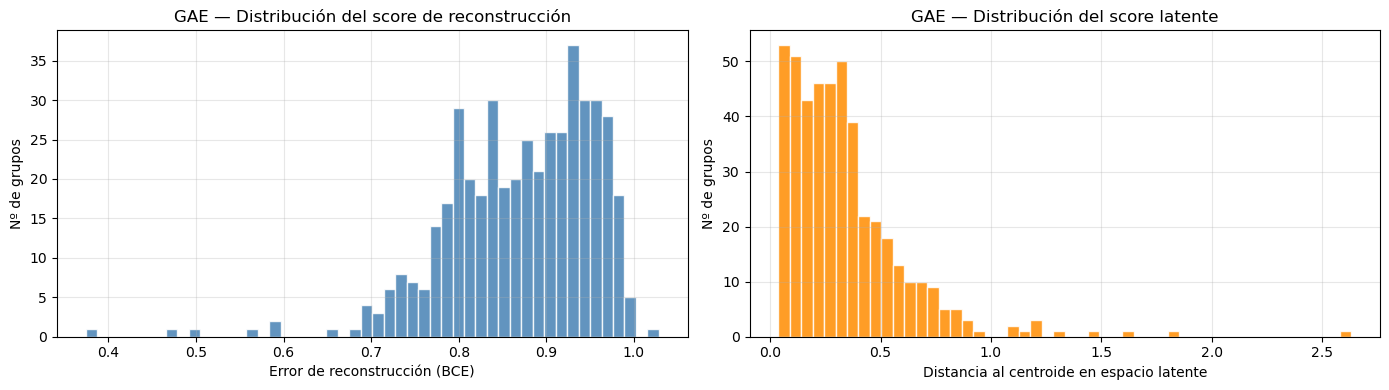

In [11]:
# Distribuciones de los dos scores
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(recon_err_gae, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Error de reconstrucción (BCE)')
axes[0].set_ylabel('Nº de grupos')
axes[0].set_title('GAE — Distribución del score de reconstrucción')
axes[0].grid(alpha=0.3)

axes[1].hist(latent_dist_gae, bins=50, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Distancia al centroide en espacio latente')
axes[1].set_ylabel('Nº de grupos')
axes[1].set_title('GAE — Distribución del score latente')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

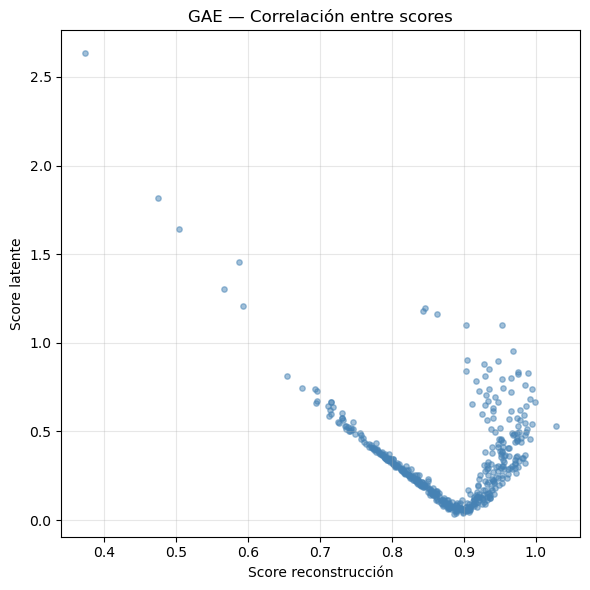

Pearson r = -0.3359


In [12]:
# Correlación entre los dos scores del GAE
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(recon_err_gae, latent_dist_gae, s=15, alpha=0.5, color='steelblue')
ax.set_xlabel('Score reconstrucción')
ax.set_ylabel('Score latente')
ax.set_title('GAE — Correlación entre scores')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

corr = np.corrcoef(recon_err_gae, latent_dist_gae)[0, 1]
print(f'Pearson r = {corr:.4f}')

## 7. Arquitectura y entrenamiento del VGAE### 7.1 Recordatorio teórico — del GAE al VGAEEl **Variational Graph Autoencoder** (Kipf & Welling, 2016) es la versión probabilística del GAE. La diferencia conceptual fundamental es que cada nodo no se proyecta a un **punto** en el espacio latente sino a una **distribución gaussiana** en ese espacio.Formalmente, en lugar de aprender una función determinista $z_i = f(X, A)_i$, aprendemos una distribución posterior aproximada:$$q(z_i \mid X, A) = \mathcal{N}(z_i \mid \mu_i, \text{diag}(\sigma_i^2))$$donde $\mu_i$ y $\sigma_i^2$ son producidos por dos GCNs separadas (que comparten una primera capa común). Para que esto sea entrenable mediante backpropagation a través de un muestreo aleatorio se usa el **truco de reparametrización**:$$z_i = \mu_i + \sigma_i \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$Esta reformulación pasa la aleatoriedad a la variable auxiliar $\epsilon$, permitiendo que los gradientes fluyan a través de $\mu_i$ y $\sigma_i$ sin problemas.### 7.2 La pérdida del VGAE — ELBOEl VGAE no minimiza solo el error de reconstrucción. Maximiza la **Evidence Lower Bound** (ELBO), una cota inferior de la log-verosimilitud de los datos:$$\mathcal{L}_{ELBO} = \mathbb{E}_{q(Z|X,A)}[\log p(A \mid Z)] - \text{KL}[q(Z \mid X, A) \| p(Z)]$$El primer término es el **error de reconstrucción** esperado (BCE de aristas, igual que en GAE). El segundo es el término de **regularización KL**, que mide cuánto se aleja la distribución posterior aprendida $q$ del prior $p(Z) = \mathcal{N}(0, I)$:$$\text{KL}[\mathcal{N}(\mu_i, \sigma_i^2) \| \mathcal{N}(0, I)] = -\frac{1}{2} \sum_{d} (1 + \log \sigma_{i,d}^2 - \mu_{i,d}^2 - \sigma_{i,d}^2)$$En la práctica, minimizamos $-\mathcal{L}_{ELBO}$, que se convierte en **pérdida de reconstrucción + KL**.### 7.3 ¿Qué aporta el VGAE frente al GAE?Tres ventajas principales:**Espacio latente más estructurado y suave.** La regularización KL fuerza a que los embeddings se distribuyan de forma cercana a una gaussiana centrada en cero. Esto evita que el modelo coloque cada nodo en una zona "propia" del espacio sin solapamiento — algo que un GAE puede hacer y que perjudica la generalización.**Cuantificación de incertidumbre.** Para cada nodo el modelo aprende no solo una posición ($\mu_i$) sino una varianza ($\sigma_i^2$). Una varianza alta indica que el modelo no está seguro de la representación de ese nodo — una señal potencialmente útil para detección de anomalías que el GAE no proporciona.**Mejor generalización en grafos pequeños.** La regularización KL actúa como una segunda forma de regularización (junto al dropout y al weight decay), particularmente útil cuando hay riesgo de sobreajuste — exactamente nuestro caso en G.### 7.4 Decisiones específicas para GReplicamos las mismas medidas de regularización que en el GAE: dropout 0.4, latent dim 8, weight decay 5e-4. La regularización KL se suma a estas — no las sustituye. El resultado es un modelo **doblemente regularizado**, lo cual es apropiado para 456 nodos.El único punto que merece comentario aparte es la **inicialización de mu**. Por construcción, en las primeras épocas los logvar son cercanos a cero (porque los pesos se inicializan pequeños), lo que hace que $\sigma_i \approx 1$ y el muestreo $z_i = \mu_i + \epsilon$ introduzca mucho ruido. Esto puede hacer que la pérdida de reconstrucción inicial sea inestable. Se observa típicamente que la `kl_loss` empieza alta y va bajando conforme el modelo aprende a hacer las distribuciones más estrechas.

In [13]:
class VariationalGCNEncoder(nn.Module):
    """
    Encoder variacional: una capa GCN compartida + dos cabezas finales,
    una para mu y otra para logvar. Versión con dropout 0.4.
    """
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.4):
        super().__init__()
        self.conv_shared = GCNConv(in_channels, hidden_channels, cached=True)
        self.conv_mu     = GCNConv(hidden_channels, out_channels, cached=True)
        self.conv_logvar = GCNConv(hidden_channels, out_channels, cached=True)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv_shared(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        mu     = self.conv_mu(x, edge_index)
        logvar = self.conv_logvar(x, edge_index)
        return mu, logvar


# Reseteamos seeds para entrenar el VGAE en condiciones equivalentes al GAE
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

model_vgae = VGAE(VariationalGCNEncoder(IN_DIM, HIDDEN_DIM, LATENT_DIM, dropout=DROPOUT)).to(device)
print(model_vgae)

n_params_v = sum(p.numel() for p in model_vgae.parameters() if p.requires_grad)
print(f'\nParámetros entrenables: {n_params_v}')
print(f'Ratio parámetros/nodo : {n_params_v / data_G.num_nodes:.2f}')

VGAE(
  (encoder): VariationalGCNEncoder(
    (conv_shared): GCNConv(35, 32)
    (conv_mu): GCNConv(32, 8)
    (conv_logvar): GCNConv(32, 8)
  )
  (decoder): InnerProductDecoder()
)

Parámetros entrenables: 1680
Ratio parámetros/nodo : 3.68


In [14]:
def train_epoch_vgae(model, data, optimizer):
    """Una época de entrenamiento del VGAE: BCE de reconstrucción + KL."""
    model.train()
    optimizer.zero_grad()
    z = model.encode(data.x, data.edge_index)
    loss = model.recon_loss(z, data.pos_edge_label_index)
    # 1/N normaliza el término KL respecto al número de nodos
    kl_loss = (1 / data.num_nodes) * model.kl_loss()
    total_loss = loss + kl_loss
    total_loss.backward()
    optimizer.step()
    return float(total_loss), float(loss), float(kl_loss)


@torch.no_grad()
def eval_split_vgae(model, data):
    model.eval()
    z = model.encode(data.x, data.edge_index)
    auc, ap = model.test(z, data.pos_edge_label_index, data.neg_edge_label_index)
    return auc, ap

In [15]:
optimizer_vgae = torch.optim.Adam(model_vgae.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

history_vgae = {'loss': [], 'rec': [], 'kl': [], 'val_auc': [], 'val_ap': []}
best_val_auc_v = 0.0
best_epoch_v = 0
patience_counter = 0
best_state_v = None

for epoch in range(1, EPOCHS + 1):
    total, rec, kl = train_epoch_vgae(model_vgae, train_data, optimizer_vgae)
    val_auc, val_ap = eval_split_vgae(model_vgae, val_data)

    history_vgae['loss'].append(total)
    history_vgae['rec'].append(rec)
    history_vgae['kl'].append(kl)
    history_vgae['val_auc'].append(val_auc)
    history_vgae['val_ap'].append(val_ap)

    if val_auc > best_val_auc_v:
        best_val_auc_v = val_auc
        best_epoch_v = epoch
        patience_counter = 0
        best_state_v = {k: v.detach().clone() for k, v in model_vgae.state_dict().items()}
    else:
        patience_counter += 1

    if epoch % 20 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | Total {total:.4f} | Rec {rec:.4f} | KL {kl:.4f} | '
              f'Val AUC {val_auc:.4f} | Val AP {val_ap:.4f}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping en época {epoch}. Mejor época: {best_epoch_v} (Val AUC {best_val_auc_v:.4f})')
        break

if best_state_v is not None:
    model_vgae.load_state_dict(best_state_v)

test_auc_v, test_ap_v = eval_split_vgae(model_vgae, test_data)
print(f'\n=== Resultados finales VGAE ===')
print(f'Test AUC: {test_auc_v:.4f}')
print(f'Test AP : {test_ap_v:.4f}')

Epoch   1 | Total 2.9606 | Rec 2.9601 | KL 0.0006 | Val AUC 0.8602 | Val AP 0.8622
Epoch  20 | Total 1.4532 | Rec 1.4477 | KL 0.0055 | Val AUC 0.8647 | Val AP 0.8710
Epoch  40 | Total 1.2294 | Rec 1.2149 | KL 0.0145 | Val AUC 0.8628 | Val AP 0.8711

Early stopping en época 56. Mejor época: 26 (Val AUC 0.8665)

=== Resultados finales VGAE ===
Test AUC: 0.8693
Test AP : 0.8734


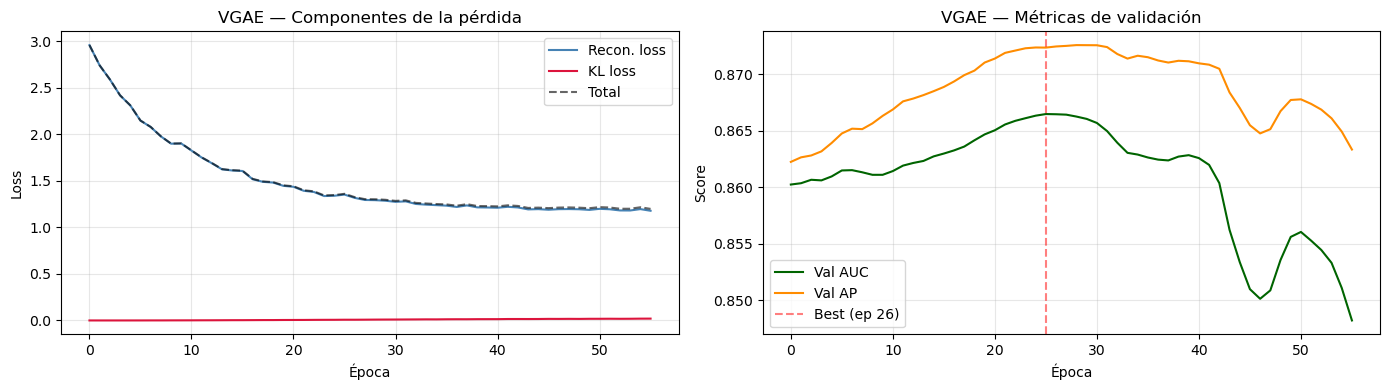

In [16]:
# Curvas de entrenamiento del VGAE — incluye desglose de la pérdida
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_vgae['rec'], label='Recon. loss', color='steelblue')
axes[0].plot(history_vgae['kl'],  label='KL loss',     color='crimson')
axes[0].plot(history_vgae['loss'], label='Total',       color='black', linestyle='--', alpha=0.6)
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].set_title('VGAE — Componentes de la pérdida')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_vgae['val_auc'], label='Val AUC', color='darkgreen')
axes[1].plot(history_vgae['val_ap'],  label='Val AP',  color='darkorange')
axes[1].axvline(best_epoch_v - 1, color='red', linestyle='--', alpha=0.5, label=f'Best (ep {best_epoch_v})')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Score')
axes[1].set_title('VGAE — Métricas de validación')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Anomaly scores (VGAE)Repetimos el cálculo de los dos scores con el VGAE. Como en el notebook 05a, usamos $\mu_i$ como embedding determinista — más estable que muestrear $z_i$ y suficiente para detección de anomalías.**Nota sobre la implementación de PyG.** Cuando llamamos a `model.encode(...)` en modo `eval()`, la implementación de PyG del VGAE devuelve directamente `mu` (el muestreo solo ocurre en `train()`). Esto es lo que queremos para obtener embeddings reproducibles.

In [17]:
@torch.no_grad()
def get_embeddings_vgae(model, data):
    """
    Devuelve los embeddings del VGAE.
    En modo eval, model.encode devuelve mu (sin muestreo).
    """
    model.eval()
    z = model.encode(data.x, data.edge_index)
    return z


z_vgae = get_embeddings_vgae(model_vgae, train_data)
print(f'VGAE embeddings shape: {z_vgae.shape}')

# Score 1 — error de reconstrucción
recon_err_vgae = reconstruction_error_per_node_dense(z_vgae, full_edge_index, data_G.num_nodes)
print(f'Reconstruction error — min={recon_err_vgae.min():.4f}, max={recon_err_vgae.max():.4f}, mean={recon_err_vgae.mean():.4f}')

# Score 2 — distancia al centroide
z_vgae_np = z_vgae.cpu().numpy()
centroid_v = z_vgae_np.mean(axis=0)
latent_dist_vgae = np.linalg.norm(z_vgae_np - centroid_v, axis=1)
print(f'Latent distance   — min={latent_dist_vgae.min():.4f}, max={latent_dist_vgae.max():.4f}, mean={latent_dist_vgae.mean():.4f}')

VGAE embeddings shape: torch.Size([456, 8])
Reconstruction error — min=0.4820, max=0.8919, mean=0.7778
Latent distance   — min=0.0345, max=1.9861, mean=0.3721


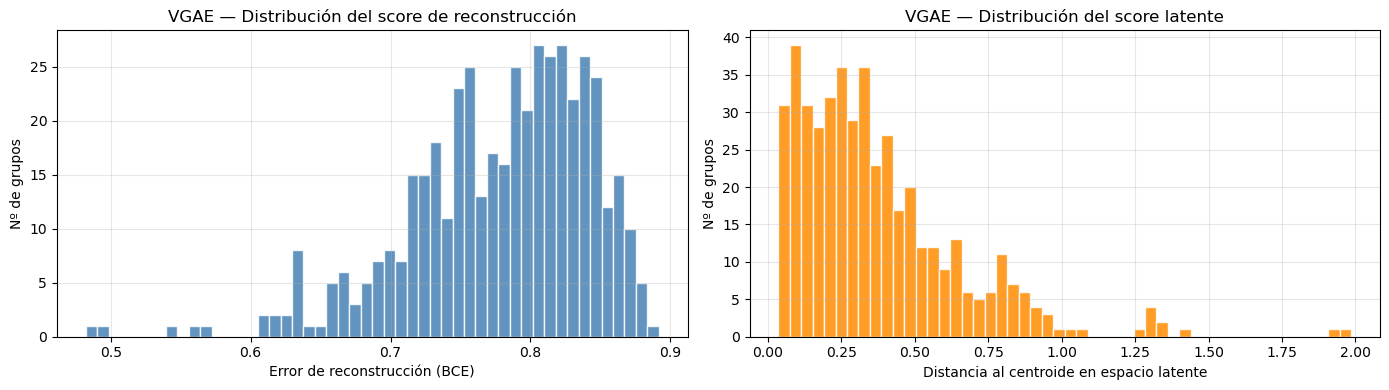

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(recon_err_vgae, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Error de reconstrucción (BCE)')
axes[0].set_ylabel('Nº de grupos')
axes[0].set_title('VGAE — Distribución del score de reconstrucción')
axes[0].grid(alpha=0.3)

axes[1].hist(latent_dist_vgae, bins=50, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Distancia al centroide en espacio latente')
axes[1].set_ylabel('Nº de grupos')
axes[1].set_title('VGAE — Distribución del score latente')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Comparativa GAE vs VGAEComparamos los dos modelos en tres dimensiones:1. **Métricas de evaluación** (AUC, AP en test). Mide la capacidad discriminativa global.2. **Correlación de rankings** (Spearman). Mide si ambos modelos identifican los mismos nodos como anómalos, en el mismo orden relativo.3. **Solapamiento del top-K**. Métrica más exigente: de los K nodos más anómalos según cada modelo, ¿cuántos coinciden literalmente?La razón de mirar las tres dimensiones es que pueden contar historias distintas. Es perfectamente posible que dos modelos tengan AUC similar pero identifiquen subconjuntos distintos de anomalías — algo que solo se ve en el solapamiento del top-K.Nota: usamos K=50 (vs K=100 en el notebook M) porque G tiene solo 456 nodos — un top-50 ya supone el 11% del grafo, una fracción razonable.

In [19]:
metrics_df = pd.DataFrame({
    'Modelo':   ['GAE', 'VGAE'],
    'Test AUC': [test_auc, test_auc_v],
    'Test AP':  [test_ap,  test_ap_v],
    'Best epoch': [best_epoch, best_epoch_v],
})
print('=== Comparativa de modelos ===')
print(metrics_df.to_string(index=False))

=== Comparativa de modelos ===
Modelo  Test AUC  Test AP  Best epoch
   GAE  0.874002 0.877176           5
  VGAE  0.869269 0.873444          26


In [20]:
from scipy.stats import spearmanr

def rank_corr(s1, s2):
    rho, _ = spearmanr(s1, s2)
    return rho

print('=== Correlación de rankings (Spearman) ===')
print(f'GAE-rec   vs VGAE-rec  : {rank_corr(recon_err_gae,   recon_err_vgae):.4f}')
print(f'GAE-lat   vs VGAE-lat  : {rank_corr(latent_dist_gae, latent_dist_vgae):.4f}')
print(f'GAE-rec   vs GAE-lat   : {rank_corr(recon_err_gae,   latent_dist_gae):.4f}')
print(f'VGAE-rec  vs VGAE-lat  : {rank_corr(recon_err_vgae,  latent_dist_vgae):.4f}')

=== Correlación de rankings (Spearman) ===
GAE-rec   vs VGAE-rec  : 0.9673
GAE-lat   vs VGAE-lat  : 0.9637
GAE-rec   vs GAE-lat   : -0.0599
VGAE-rec  vs VGAE-lat  : -0.1186


In [21]:
def top_k_overlap(s1, s2, k=50):
    top1 = set(np.argsort(-s1)[:k])
    top2 = set(np.argsort(-s2)[:k])
    return len(top1 & top2) / k

K = 50
print(f'=== Solapamiento del top-{K} ({K/data_G.num_nodes*100:.1f}% del grafo) ===')
print(f'GAE-rec   vs VGAE-rec : {top_k_overlap(recon_err_gae,   recon_err_vgae,   K):.2%}')
print(f'GAE-lat   vs VGAE-lat : {top_k_overlap(latent_dist_gae, latent_dist_vgae, K):.2%}')
print(f'GAE-rec   vs GAE-lat  : {top_k_overlap(recon_err_gae,   latent_dist_gae,  K):.2%}')
print(f'VGAE-rec  vs VGAE-lat : {top_k_overlap(recon_err_vgae,  latent_dist_vgae, K):.2%}')

=== Solapamiento del top-50 (11.0% del grafo) ===
GAE-rec   vs VGAE-rec : 78.00%
GAE-lat   vs VGAE-lat : 86.00%
GAE-rec   vs GAE-lat  : 22.00%
VGAE-rec  vs VGAE-lat : 10.00%


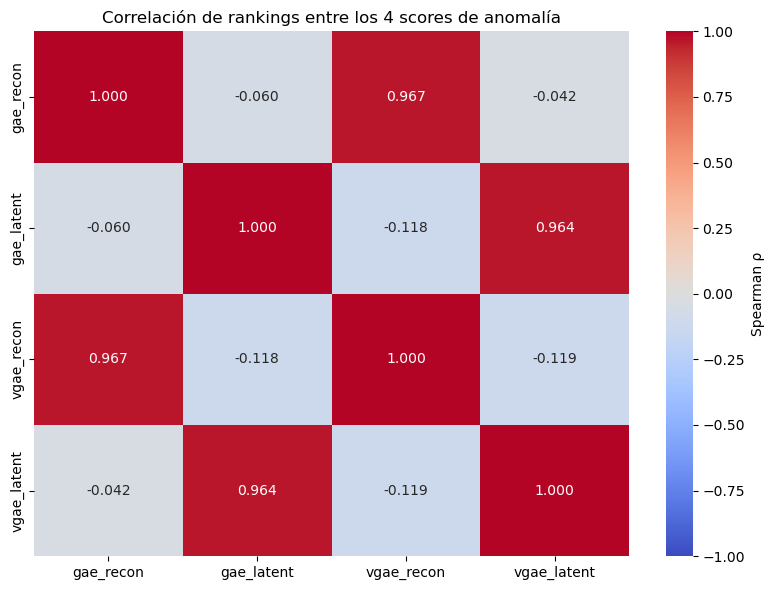

In [22]:
def normalize(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-9)

scores_df = pd.DataFrame({
    'gae_recon':   normalize(recon_err_gae),
    'gae_latent':  normalize(latent_dist_gae),
    'vgae_recon':  normalize(recon_err_vgae),
    'vgae_latent': normalize(latent_dist_vgae),
})

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(scores_df.corr(method='spearman'), annot=True, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=ax, fmt='.3f', cbar_kws={'label': 'Spearman ρ'})
ax.set_title('Correlación de rankings entre los 4 scores de anomalía')
plt.tight_layout()
plt.show()

## 10. Análisis de anomalías detectadasConstruimos una tabla de scores por nodo y la cruzamos con `meta_groups` para interpretar los resultados. El EDA del grafo G identificó varios candidatos a anomalía estructural — verificamos si aparecen en el top-K de los modelos:- **28 grupos hoja** (grado = 1).- **Stepping Out Social Dance Meetup** — grupo más conectado (grado 182) con solo 1.778 miembros — desproporcionadamente conectado para su tamaño.- **Nashville Hiking Meetup** — caso opuesto: 15.838 miembros pero grado 136. Miembros relativamente exclusivos.- **Nashville Children in Nature** — 654 miembros pero clustering = 0, completamente aislado estructuralmente.- **Microcomunidades C0 (2 nodos) y C3 (4 nodos, Religion & Beliefs)** — incluido el peculiar grupo "Christianity & Transhumanism".- **NashJS** — hub tecnológico extremo, aparece en 6 de las 10 aristas más fuertes.- **35 grupos sin organizador válido** (anomalía de integridad referencial).

In [23]:
# Construimos un DataFrame con todos los scores por nodo
group_ids_G = data_G.group_ids  # lista de group_id en el orden de los índices del grafo

scores_full = pd.DataFrame({
    'idx':         np.arange(data_G.num_nodes),
    'group_id':    group_ids_G,
    'gae_recon':   recon_err_gae,
    'gae_latent':  latent_dist_gae,
    'vgae_recon':  recon_err_vgae,
    'vgae_latent': latent_dist_vgae,
})

# Calculamos también el grado de cada nodo en el grafo original
degree = torch.zeros(data_G.num_nodes, dtype=torch.long)
degree.scatter_add_(0, data_G.edge_index[0].cpu(), torch.ones(data_G.edge_index.shape[1], dtype=torch.long))
scores_full['degree'] = degree.numpy() // 2  # /2 porque cada arista está duplicada

# Cruzamos con meta_groups
scores_full = scores_full.merge(
    meta_groups[['group_id', 'group_name', 'category_name', 'num_members']],
    on='group_id', how='left'
)

print(f'Shape: {scores_full.shape}')
scores_full.head()

Shape: (456, 10)


,idx,group_id,gae_recon,gae_latent,vgae_recon,vgae_latent,degree,group_name,category_name,num_members
0,0,339011,0.952537,1.100138,0.822861,1.281901,68,Nashville Hiking Meetup,Outdoors & Adventure,15838
1,1,19728145,0.846451,1.193849,0.736910,1.431667,91,Stepping Out Social Dance Meetup,Dancing,1778
2,2,6335372,0.961297,0.406814,0.854690,0.489674,29,Nashville soccer,Sports & Recreation,2869
3,3,10016242,0.930097,0.703584,0.811708,0.785242,53,NashJS,Tech,1975
4,4,21174496,0.973119,0.578357,0.860260,0.690519,38,20's & 30's Women looking for girlfriends,Socializing,2782


In [24]:
# Top 20 anómalos según GAE - reconstrucción
print('=== Top 20 — GAE reconstruction error ===')
top20_gae_rec = scores_full.nlargest(20, 'gae_recon')[
    ['group_name', 'category_name', 'num_members', 'degree', 'gae_recon']
]
print(top20_gae_rec.to_string(index=False))

=== Top 20 — GAE reconstruction error ===
                                                  group_name              category_name  num_members  degree  gae_recon
                Spiritual Psychology and Consciousness Group     New Age & Spirituality         1382      28   1.028381
                                    Nashville Spanish Meetup Language & Ethnic Identity         1417      40   0.998824
                      Tennessee Real Estate Investors Meetup          Career & Business         1292      31   0.995143
Fun Happenings Social Group-Nashvilles Most Fun Social Group                Socializing         2050      44   0.993896
                                          Tails of the Trail             Pets & Animals         1241      41   0.992359
                         Women 'n' Wine of Williamson County          Career & Business          959      28   0.992326
                                    Nashville Psychic Meetup     New Age & Spirituality         2360      49   0.98853

In [25]:
# Top 20 anómalos según GAE - latent distance
print('=== Top 20 — GAE latent distance ===')
top20_gae_lat = scores_full.nlargest(20, 'gae_latent')[
    ['group_name', 'category_name', 'num_members', 'degree', 'gae_latent']
]
print(top20_gae_lat.to_string(index=False))

=== Top 20 — GAE latent distance ===
                                             group_name              category_name  num_members  degree  gae_latent
                                                Ingress                      Games           11       1    2.632889
                                Nashville Squash Meetup        Sports & Recreation           47       0    1.816815
                     Nashville League of Legends Meetup                      Games           94       0    1.644605
                               10X Revolution Nashville         Health & Wellbeing           51       0    1.454290
                  Portuguese Language Club in Nashville Language & Ethnic Identity           50       0    1.305043
                                        TwitchNashville                      Games          187       1    1.208712
                       Stepping Out Social Dance Meetup                    Dancing         1778      91    1.193849
                                   

In [26]:
# Top 20 anómalos según VGAE - reconstrucción
print('=== Top 20 — VGAE reconstruction error ===')
top20_vgae_rec = scores_full.nlargest(20, 'vgae_recon')[
    ['group_name', 'category_name', 'num_members', 'degree', 'vgae_recon']
]
print(top20_vgae_rec.to_string(index=False))

=== Top 20 — VGAE reconstruction error ===
                                                  group_name              category_name  num_members  degree  vgae_recon
                Spiritual Psychology and Consciousness Group     New Age & Spirituality         1382      28    0.891875
                                          Tails of the Trail             Pets & Animals         1241      41    0.880657
         Middle Tennessee Sierra Club Outings and Adventures    Community & Environment         3509      22    0.877397
                                 Nashville Backpacker Meetup       Outdoors & Adventure         3861      30    0.877009
                                     Nashville Kayak Lessons       Outdoors & Adventure         3260      16    0.876013
       Movie Lovers:  New, Classic, and Foreign Films Meetup              Movies & Film          875      31    0.875502
                Mount Juliet/Wilson County Hiking & Outdoors       Outdoors & Adventure          802      21  

In [27]:
# Top 20 anómalos según VGAE - latent distance
print('=== Top 20 — VGAE latent distance ===')
top20_vgae_lat = scores_full.nlargest(20, 'vgae_latent')[
    ['group_name', 'category_name', 'num_members', 'degree', 'vgae_latent']
]
print(top20_vgae_lat.to_string(index=False))

=== Top 20 — VGAE latent distance ===
                                             group_name              category_name  num_members  degree  vgae_latent
                               10X Revolution Nashville         Health & Wellbeing           51       0     1.986140
                                                Ingress                      Games           11       1     1.938168
                       Stepping Out Social Dance Meetup                    Dancing         1778      91     1.431667
                     Nashville League of Legends Meetup                      Games           94       0     1.340226
                                Nashville Squash Meetup        Sports & Recreation           47       0     1.331900
                                          Eat Love Nash                Socializing         5008      88     1.306008
                                          What the Pho!               Food & Drink         1889      84     1.300554
                  Portugue

In [28]:
# Verificación: ¿los grupos hoja salen como anómalos?
leaf_groups = scores_full[scores_full['degree'] == 1]
print(f'Grupos hoja en el dataset: {len(leaf_groups)}')
print('\n=== Posición de cada grupo hoja en el ranking de cada score ===')
for _, row in leaf_groups.head(15).iterrows():
    rank_gr = (scores_full['gae_recon']   > row['gae_recon']).sum()   + 1
    rank_gl = (scores_full['gae_latent']  > row['gae_latent']).sum()  + 1
    rank_vr = (scores_full['vgae_recon']  > row['vgae_recon']).sum()  + 1
    rank_vl = (scores_full['vgae_latent'] > row['vgae_latent']).sum() + 1
    name_short = str(row['group_name'])[:40]
    print(f"  {name_short:40s} | GAE-rec #{rank_gr:3d} | GAE-lat #{rank_gl:3d} | "
          f"VGAE-rec #{rank_vr:3d} | VGAE-lat #{rank_vl:3d}")

Grupos hoja en el dataset: 47

=== Posición de cada grupo hoja en el ranking de cada score ===
  Nashville Drum Circle Community :D       | GAE-rec #392 | GAE-lat #154 | VGAE-rec #402 | VGAE-lat #133
  Hendersonville Area Active/Outdoor Lifes | GAE-rec #412 | GAE-lat #117 | VGAE-rec #385 | VGAE-lat #164
  Women, Wine, & Coloring                  | GAE-rec #373 | GAE-lat #170 | VGAE-rec #414 | VGAE-lat #115
  TwitchNashville                          | GAE-rec #451 | GAE-lat #  6 | VGAE-rec #443 | VGAE-lat # 41
  Nashville Girl's Night Out - Shopping, N | GAE-rec #402 | GAE-lat #131 | VGAE-rec #395 | VGAE-lat #148
  Middle Tennessee Photography Buddies     | GAE-rec #379 | GAE-lat #168 | VGAE-rec #381 | VGAE-lat #167
  The Costumed Revelers                    | GAE-rec #421 | GAE-lat # 94 | VGAE-rec #427 | VGAE-lat # 76
  The Country Club of Downtown Nashville ( | GAE-rec #388 | GAE-lat #165 | VGAE-rec #345 | VGAE-lat #227
  RfR - Nashville, TN                      | GAE-rec #443 | GAE-l

In [29]:
# Verificación: ¿los grupos extremos del EDA salen como anómalos?
candidates = [
    'Stepping Out Social Dance Meetup',
    'Nashville Hiking Meetup',
    'Nashville Children in Nature',
    'NashJS',
    'Christianity & Transhumanism',
    'Nashville Social Crew',
]

print('=== Ranking de candidatos a anomalía identificados en el EDA ===')
for name in candidates:
    matches = scores_full[scores_full['group_name'].str.contains(name, case=False, na=False)]
    if len(matches) == 0:
        print(f'  [no encontrado] {name}')
        continue
    for _, row in matches.iterrows():
        rank_gr = (scores_full['gae_recon']   > row['gae_recon']).sum()   + 1
        rank_gl = (scores_full['gae_latent']  > row['gae_latent']).sum()  + 1
        rank_vr = (scores_full['vgae_recon']  > row['vgae_recon']).sum()  + 1
        rank_vl = (scores_full['vgae_latent'] > row['vgae_latent']).sum() + 1
        name_short = str(row['group_name'])[:35]
        print(f"  {name_short:35s} | grado {row['degree']:3d} | members {row['num_members']:5d} | "
              f"GAE-rec #{rank_gr:3d} | GAE-lat #{rank_gl:3d} | "
              f"VGAE-rec #{rank_vr:3d} | VGAE-lat #{rank_vl:3d}")

=== Ranking de candidatos a anomalía identificados en el EDA ===
  Stepping Out Social Dance Meetup    | grado  91 | members  1778 | GAE-rec #284 | GAE-lat #  7 | VGAE-rec #343 | VGAE-lat #  3
  Nashville Hiking Meetup             | grado  68 | members 15838 | GAE-rec # 71 | GAE-lat # 10 | VGAE-rec #129 | VGAE-lat # 10
  Nashville Children in Nature        | grado   0 | members   654 | GAE-rec #350 | GAE-lat #195 | VGAE-rec #356 | VGAE-lat #200
  NashJS                              | grado  53 | members  1975 | GAE-rec #133 | GAE-lat # 35 | VGAE-rec #159 | VGAE-lat # 43
  Christianity & Transhumanism        | grado   2 | members    31 | GAE-rec #422 | GAE-lat # 68 | VGAE-rec #431 | VGAE-lat # 68
  [no encontrado] Nashville Social Crew


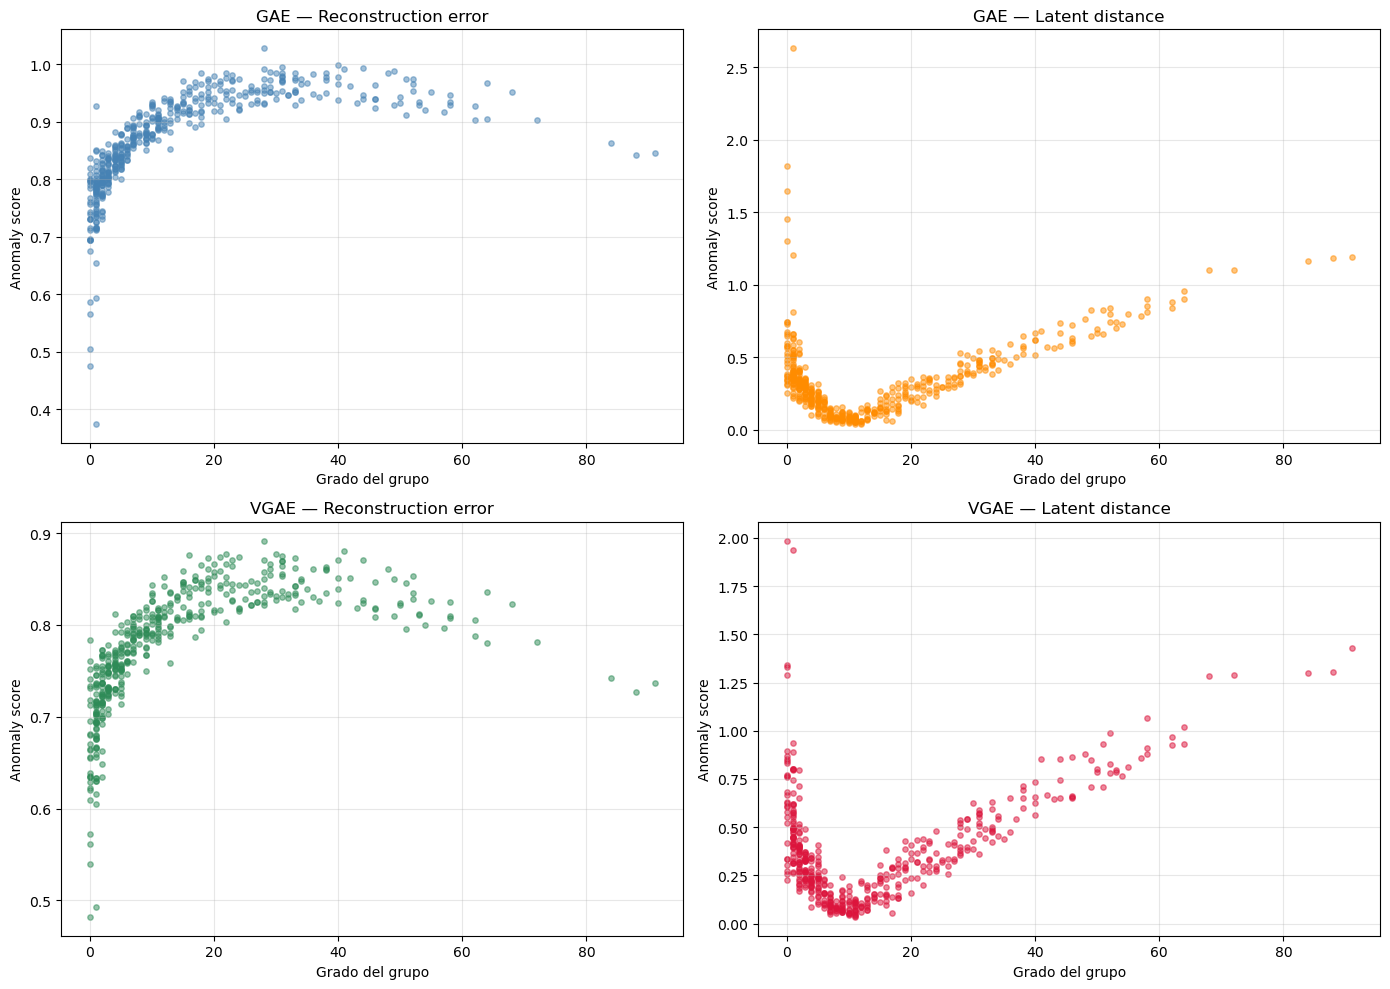

In [30]:
# Visualización: scatter degree vs cada score
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

scatters = [
    ('gae_recon',   'GAE — Reconstruction error',   axes[0, 0], 'steelblue'),
    ('gae_latent',  'GAE — Latent distance',        axes[0, 1], 'darkorange'),
    ('vgae_recon',  'VGAE — Reconstruction error',  axes[1, 0], 'seagreen'),
    ('vgae_latent', 'VGAE — Latent distance',       axes[1, 1], 'crimson'),
]

for col, title, ax, color in scatters:
    ax.scatter(scores_full['degree'], scores_full[col], s=15, alpha=0.5, color=color)
    ax.set_xlabel('Grado del grupo')
    ax.set_ylabel('Anomaly score')
    ax.set_title(title)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\marco\AppData\Local\Temp\ipykernel_34800\3735633553.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')


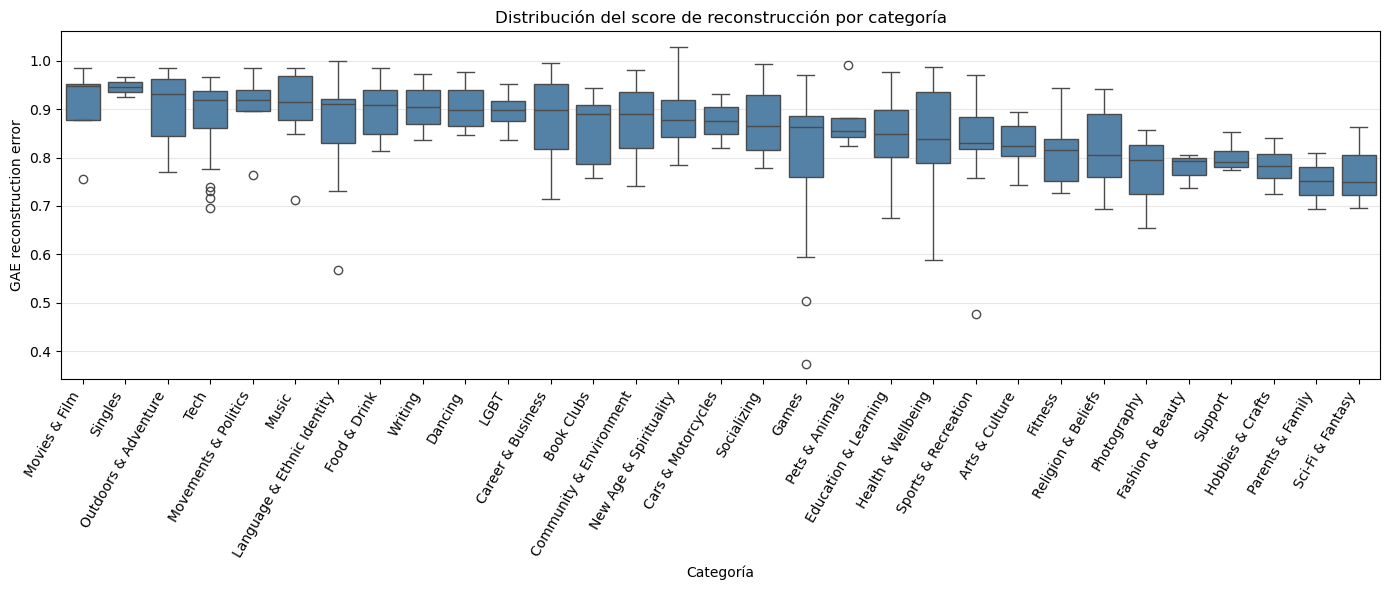

In [31]:
# Distribución de scores por categoría — útil para ver si alguna categoría es más anómala que otras
fig, ax = plt.subplots(figsize=(14, 6))
order = scores_full.groupby('category_name')['gae_recon'].median().sort_values(ascending=False).index
sns.boxplot(data=scores_full, x='category_name', y='gae_recon', order=order, ax=ax, color='steelblue')
ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')
ax.set_xlabel('Categoría')
ax.set_ylabel('GAE reconstruction error')
ax.set_title('Distribución del score de reconstrucción por categoría')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 11. Guardado de resultadosGuardamos los mismos artefactos que en el notebook 05a:- **`scores_G.csv`** — tabla de scores por nodo, con metadatos cruzados. Esencial para la comparativa entre grafos en la sección 7.4 del TFM.- **`embeddings_G.npz`** — embeddings de ambos modelos. Se podrán reutilizar para visualizaciones (por ejemplo, t-SNE o UMAP en los anexos).- **`history_G.json`** — historial de entrenamiento y configuración de hiperparámetros, para reproducibilidad y para regenerar las gráficas de la memoria sin reentrenar.

In [32]:
# CSV de scores por nodo
scores_full.to_csv(os.path.join(RESULTS_PATH, 'scores_G.csv'), index=False)
print(f'Guardado: {RESULTS_PATH}scores_G.csv  ({scores_full.shape})')

# Embeddings
np.savez(
    os.path.join(RESULTS_PATH, 'embeddings_G.npz'),
    z_gae=z_np,
    z_vgae=z_vgae_np,
    group_ids=np.array(group_ids_G),
)
print(f'Guardado: {RESULTS_PATH}embeddings_G.npz')

# Historial de entrenamiento
import json
history_export = {
    'gae': {k: list(map(float, v)) for k, v in history_gae.items()},
    'vgae': {k: list(map(float, v)) for k, v in history_vgae.items()},
    'metrics': {
        'gae':  {'test_auc': float(test_auc),   'test_ap': float(test_ap),   'best_epoch': int(best_epoch)},
        'vgae': {'test_auc': float(test_auc_v), 'test_ap': float(test_ap_v), 'best_epoch': int(best_epoch_v)},
    },
    'config': {
        'hidden_dim': HIDDEN_DIM, 'latent_dim': LATENT_DIM,
        'dropout': DROPOUT, 'lr': LR, 'weight_decay': WEIGHT_DECAY,
        'epochs': EPOCHS, 'patience': PATIENCE, 'seed': SEED,
    }
}
with open(os.path.join(RESULTS_PATH, 'history_G.json'), 'w') as f:
    json.dump(history_export, f, indent=2)
print(f'Guardado: {RESULTS_PATH}history_G.json')

Guardado: ../data/results/scores_G.csv  ((456, 10))
Guardado: ../data/results/embeddings_G.npz
Guardado: ../data/results/history_G.json


## Resumen del notebookEn este notebook hemos:1. **Analizado las diferencias del grafo G respecto a M** y justificado por qué necesita más regularización (ratio de parámetros por nodo ~70× mayor, riesgo de sobreajuste alto).2. **Aplicado tres técnicas de regularización adicionales** respecto al notebook 05a: dropout 0.4, weight decay 5e-4, dimensión latente 8.3. **Entrenado un GAE y un VGAE** sobre el grafo de grupos con la misma metodología que en M, adaptada al tamaño del grafo.4. **Calculado los dos scores de anomalía** por modelo (reconstrucción y latente).5. **Comparado los rankings** mediante correlación de Spearman y solapamiento del top-50.6. **Verificado los candidatos del EDA** — Stepping Out Social Dance, Nashville Hiking, NashJS, Christianity & Transhumanism, etc.7. **Analizado la distribución de scores por categoría temática**, que añade una dimensión interpretativa específica del grafo G.Los resultados quedan guardados en `data/results/` para su uso en el notebook 05c (grafo bipartito MG) y en la sección de discusión del TFM.